# Readers

Notebook was prepared as a sample tool to read data from different data sources. Moreover notebook includes some simple exploratory data analysis for data overview purposes.

In [1]:
import os
import sys
from pathlib import Path
from pprint import pprint as print

import requests
import pandas as pd
import numpy as np


# Setup pitch and plot
from mplsoccer import Pitch, VerticalPitch


In [2]:
CURRENT_WORKING_DIR = Path(os.getcwd())
WORKING_DIR = CURRENT_WORKING_DIR.parent
DATA_DIR = WORKING_DIR / "data"

sys.path.append(str(WORKING_DIR))

## SkillCorner

Data loading is based on the SkillCorner tutorial guide. More information under below link :arrow_down:

**Link:** https://github.com/SkillCorner/opendata

In [3]:
# Content URL for the SkillCorner opendata repository
content_url = "https://api.github.com/repos/SkillCorner/opendata/contents/data/matches"

# Get the list of available matches
response = requests.get(content_url)
matches = response.json()

# Display available match IDs
match_ids = [match['name'] for match in matches if match['type'] == 'dir']
print(f"Available matches: {len(match_ids)}")
print(match_ids)

'Available matches: 10'
['1886347',
 '1899585',
 '1925299',
 '1953632',
 '1996435',
 '2006229',
 '2011166',
 '2013725',
 '2015213',
 '2017461']


## Data Readers ###

In [4]:
# Example: Load tracking data for a specific match
match_id = 1886347

# Construct the raw tracking content URL
content_tracking_url = content_url + f"/{match_id}/{match_id}_tracking_extrapolated.jsonl"  # Data is stored using GitLFS
content_tracking_data = pd.read_json(content_tracking_url, lines=True)
print(f"Downloaded tracking data URL: {content_tracking_data['download_url'][0]}")

# Construct the raw match content URL
content_match_url = content_url + f"/{match_id}/{match_id}_match.json"  # Data is stored using GitLFS
content_match_data = pd.read_json(content_match_url, lines=True)
print(f"Downloaded match data URL: {content_match_data['download_url'][0]}")

('Downloaded tracking data URL: '
 'https://media.githubusercontent.com/media/SkillCorner/opendata/master/data/matches/1886347/1886347_tracking_extrapolated.jsonl')
('Downloaded match data URL: '
 'https://raw.githubusercontent.com/SkillCorner/opendata/master/data/matches/1886347/1886347_match.json')


## Player data

Extract player and ball data. Preprocess raw data frame into processed, ready for analytics data frame. 

In [5]:
from football_ml.jobs.data_gathering_job import preprocess_tracking_data

# Read the JSON tracking data as a JSON object
raw_tracking_data = pd.read_json(content_tracking_data['download_url'][0], lines=True)

# Process the raw data
processed_tracking_df = preprocess_tracking_data(raw_tracking_data)
processed_tracking_df["match_id"] = match_id
processed_tracking_df.head()

/Users/piotrpatrzalek/Documents/respository_private/football-ml/notebooks
['/opt/homebrew/anaconda3/envs/env-football-ml/lib/python310.zip', '/opt/homebrew/anaconda3/envs/env-football-ml/lib/python3.10', '/opt/homebrew/anaconda3/envs/env-football-ml/lib/python3.10/lib-dynload', '', '/opt/homebrew/anaconda3/envs/env-football-ml/lib/python3.10/site-packages', '/Users/piotrpatrzalek/Documents/respository_private/football-ml', '/Users/piotrpatrzalek/Documents/respository_private/football-ml']


,x,y,player_id,is_detected,frame,timestamp,period,possession_player_id,possession_group,ball_x,ball_y,ball_z,is_detected_ball,match_id
0,-39.63,-0.08,51009,False,10,2025-12-28,1.0,NaN,None,0.32,0.38,0.13,True,1886347
1,-19.21,-9.18,176224,True,10,2025-12-28,1.0,NaN,None,0.32,0.38,0.13,True,1886347
2,-21.83,0.47,51649,True,10,2025-12-28,1.0,NaN,None,0.32,0.38,0.13,True,1886347
3,-1.16,-32.47,50983,True,10,2025-12-28,1.0,NaN,None,0.32,0.38,0.13,True,1886347
4,-18.88,15.73,735578,True,10,2025-12-28,1.0,NaN,None,0.32,0.38,0.13,True,1886347


In [6]:
path = DATA_DIR / "raw" / "all_matches_tracking.parquet"
all_matches_tracking_df = pd.read_parquet(path)

## Match data

In [7]:
from football_ml.jobs.data_gathering_job import preprocess_players_data

# Read the JSON match data as a JSON object
response = requests.get(content_match_data['download_url'][0])
raw_match_data = response.json()
raw_match_df = pd.json_normalize(raw_match_data, max_level=2)
processed_players_df = preprocess_players_data(raw_match_df)
processed_players_df.head()

,start_time,end_time,match_id,match_name,date_time,home_team.name,away_team.name,id,short_name,number,team_id,team_name,player_role.position_group,total_time,player_role.name,player_role.acronym,is_gk,direction_player_1st_half,direction_player_2nd_half
0,00:00:00,01:25:21,1886347,Auckland FC vs Newcastle United Jets FC,2024-11-30T04:00:00Z,Auckland FC,Newcastle United Jets FC,38673,G. May,10,4177,Auckland FC,Center Forward,5121,Center Forward,CF,False,right_to_left,left_to_right
1,00:00:00,None,1886347,Auckland FC vs Newcastle United Jets FC,2024-11-30T04:00:00Z,Auckland FC,Newcastle United Jets FC,51713,C. Elliott,17,4177,Auckland FC,Full Back,5400,Right Back,RB,False,right_to_left,left_to_right
2,00:00:00,01:16:37,1886347,Auckland FC vs Newcastle United Jets FC,2024-11-30T04:00:00Z,Auckland FC,Newcastle United Jets FC,50951,J. Brimmer,22,4177,Auckland FC,Center Forward,4597,Center Forward,CF,False,right_to_left,left_to_right
3,00:00:00,01:24:58,1886347,Auckland FC vs Newcastle United Jets FC,2024-11-30T04:00:00Z,Auckland FC,Newcastle United Jets FC,50978,C. Timmins,19,1805,Newcastle United Jets FC,Midfield,5098,Left Defensive Midfield,LDM,False,left_to_right,right_to_left
4,00:00:00,None,1886347,Auckland FC vs Newcastle United Jets FC,2024-11-30T04:00:00Z,Auckland FC,Newcastle United Jets FC,133498,F. De Vries,15,4177,Auckland FC,Full Back,5400,Left Back,LB,False,right_to_left,left_to_right


In [9]:
path = DATA_DIR / "raw" / "all_matches_players.parquet"
all_matches_players_df = pd.read_parquet(path)

## Merging data frame

In [94]:
merged_df = all_matches_tracking_df.merge(
    all_matches_players_df, on=["player_id", "match_id"], how="left"
)
merged_df["time_in_minutes"] = np.round(merged_df["timestamp"].dt.hour * 60 + merged_df["timestamp"].dt.minute + merged_df["timestamp"].dt.second / 60, 2)
merged_df.head()

,x,y,player_id,is_detected,frame,timestamp,period,possession_player_id,possession_group,ball_x,...,team_id,team_name,player_role.position_group,total_time,player_role.name,player_role.acronym,is_gk,direction_player_1st_half,direction_player_2nd_half,time_in_minutes
0,-39.63,-0.08,51009,False,10,2025-12-28,1.0,NaN,None,0.32,...,1805,Newcastle United Jets FC,Other,5400,Goalkeeper,GK,True,left_to_right,right_to_left,0.0
1,-19.21,-9.18,176224,True,10,2025-12-28,1.0,NaN,None,0.32,...,1805,Newcastle United Jets FC,Central Defender,5400,Right Center Back,RCB,False,left_to_right,right_to_left,0.0
2,-21.83,0.47,51649,True,10,2025-12-28,1.0,NaN,None,0.32,...,1805,Newcastle United Jets FC,Central Defender,5400,Left Center Back,LCB,False,left_to_right,right_to_left,0.0
3,-1.16,-32.47,50983,True,10,2025-12-28,1.0,NaN,None,0.32,...,1805,Newcastle United Jets FC,Full Back,5400,Right Back,RB,False,left_to_right,right_to_left,0.0
4,-18.88,15.73,735578,True,10,2025-12-28,1.0,NaN,None,0.32,...,1805,Newcastle United Jets FC,Full Back,5400,Left Back,LB,False,left_to_right,right_to_left,0.0


In [22]:
print(f"Processed tracking data shape: {all_matches_tracking_df.shape}")
print(f"Processed players data shape: {all_matches_players_df.shape}")
print(f"Merged data shape: {merged_df.shape}")

'Processed tracking data shape: (9606256, 14)'
'Processed players data shape: (309, 19)'
'Merged data shape: (9606256, 31)'


**Analysis ideas:**
 - free kicks, corners - players movements
 - Midfielders - off ball movements, number of offensive / defensive passes, passes based on the number of opponent players
 - Center Backs - off ball movements in offensive part of the game, passes
 - Before goal team movement

**ML model ideas:**
- Clustering - players similarities
    - off ball movements

In [23]:
# Filtering for frames with a team in possession
filtered_df = merged_df[
    merged_df["possession_group"].notnull()
].copy()


# We basically want to convert the X and Y to make sure we're always visualizing left to right. A player's XY will depend on the half so the straight average doesn't work

filtered_df["direction_player"] = np.where(
    filtered_df["period"] == 1,
    filtered_df["direction_player_1st_half"],
    filtered_df["direction_player_2nd_half"],
)
filtered_df["x"] = np.where(
    filtered_df["direction_player"] == "right_to_left",
    -filtered_df["x"],
    filtered_df["x"],
)  # Convert X
filtered_df["y"] = np.where(
    filtered_df["direction_player"] == "right_to_left",
    -filtered_df["y"],
    filtered_df["y"],
)  # Convert Y

# Create some flags in case we need them later
filtered_df["possession_team_name"] = np.where(
    filtered_df["possession_group"] == "home team",
    filtered_df["home_team.name"],
    filtered_df["away_team.name"],
)
filtered_df["possession_flag"] = np.where(
    filtered_df["possession_team_name"] == filtered_df["team_name"], "IP", "OOP"
)


# At this point all of our players have their X and Y adjusted from left to right , so we can aggregate for across the game

aggregated_df = (
    filtered_df.groupby(
        [
            "player_id",
            "possession_group",
            "team_name",
            "possession_team_name",
            "possession_flag",  # This will allow us to check the position of the player when the team is in or out of possession
            "start_time",  # With this we can filter in or out the players that came on as subs
            "number",
            "is_gk",
        ]
    )[["x", "y"]]
    .mean()
    .reset_index()
)

aggregated_df.sort_values(["possession_flag", "team_name"])

,player_id,possession_group,team_name,possession_team_name,possession_flag,start_time,number,is_gk,x,y
87,26766,away team,Adelaide United Football Club,Adelaide United Football Club,IP,00:00:00,3,False,-16.383313,-9.385992
138,42513,away team,Adelaide United Football Club,Adelaide United Football Club,IP,00:00:00,10,False,4.273183,-5.330018
148,50949,away team,Adelaide United Football Club,Adelaide United Football Club,IP,00:00:00,14,False,-9.429593,-6.417311
161,50959,away team,Adelaide United Football Club,Adelaide United Football Club,IP,00:00:00,6,False,1.424930,0.009004
163,50971,away team,Adelaide United Football Club,Adelaide United Football Club,IP,01:10:46,19,False,19.725062,22.461406
...,...,...,...,...,...,...,...,...,...,...
520,818284,away team,Western United,Sydney Football Club,OOP,01:09:44,5,False,5.213837,8.768092
523,818554,away team,Western United,Auckland FC,OOP,01:11:13,20,False,0.058425,15.527067
524,818554,away team,Western United,Sydney Football Club,OOP,01:14:27,20,False,-1.317537,18.348113
539,957737,away team,Western United,Auckland FC,OOP,00:00:00,30,False,-14.480229,5.949760


# Visualization example

In [ ]:
mask = (merged_df['player_id'] == 23909) & (merged_df['match_id'] == 1899585) & ()
viz_df = merged_df[mask]

In [100]:
merged_df.columns

Index(['x', 'y', 'player_id', 'is_detected', 'frame', 'timestamp', 'period',
       'possession_player_id', 'possession_group', 'ball_x', 'ball_y',
       'ball_z', 'is_detected_ball', 'match_id', 'start_time', 'end_time',
       'match_name', 'date_time', 'home_team.name', 'away_team.name',
       'short_name', 'number', 'team_id', 'team_name',
       'player_role.position_group', 'total_time', 'player_role.name',
       'player_role.acronym', 'is_gk', 'direction_player_1st_half',
       'direction_player_2nd_half', 'time_in_minutes'],
      dtype='object')

In [128]:
!pip install nbformat==4.3.0

  Attempting uninstall: nbformat
    Found existing installation: nbformat 4.2.0
    Uninstalling nbformat-4.2.0:
      Successfully uninstalled nbformat-4.2.0


In [129]:
from plotly import graph_objects as go

mask = viz_df["period"] == 1


In [131]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=viz_df.loc[mask, 'time_in_minutes'],
    y=viz_df.loc[mask, 'x'],
    mode='lines+markers',
    name='x'
))
fig.add_trace(go.Scatter(
    x=viz_df.loc[mask, 'time_in_minutes'],
    y=viz_df.loc[mask, 'ball_x'],
    mode='lines+markers',
    name='ball_x'
))
fig.update_layout(
    title="Player X Position and Ball X Position Over Time (Period 1)",
    xaxis_title="Time (minutes)",
    yaxis_title="X Position (meters)",
    legend_title="Legend"
)
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

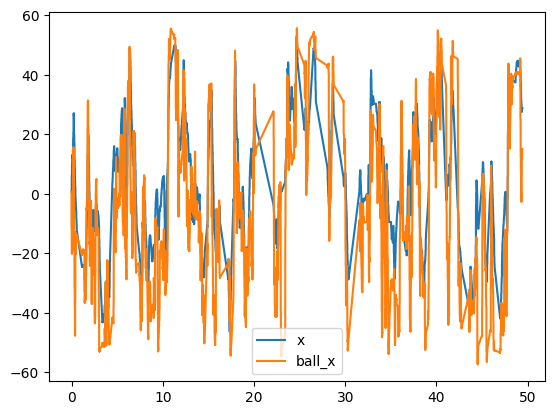

In [ ]:

# plt.scatter(viz_df.loc[mask, 'time_in_minutes'], viz_df.loc[mask, 'x'], s=10, marker='.', label='x')
plt.plot(viz_df.loc[mask, 'time_in_minutes'], viz_df.loc[mask, 'x'], label='x')
# plt.scatter(viz_df.loc[mask, 'time_in_minutes'], viz_df.loc[mask, 'ball_x'], s=10, marker='.', label='ball_x')
plt.plot(viz_df.loc[mask, 'time_in_minutes'], viz_df.loc[mask, 'ball_x'], label='ball_x')
plt.legend()

In [25]:
# Teams
aggregated_df.team_name.unique().tolist()

['Sydney Football Club',
 'Macarthur FC',
 'Auckland FC',
 'Wellington Phoenix FC',
 'Melbourne City FC',
 'Melbourne Victory Football Club',
 'Central Coast Mariners Football Club',
 'Perth Glory Football Club',
 'Western United',
 'Adelaide United Football Club',
 'Newcastle United Jets FC',
 'Brisbane Roar FC']

In [ ]:
possession = "IP"  # 'IP' or 'OOP'
team = 'Brisbane Roar FC'  # Pick one team, you can use the name directly

Text(0.5, 1.0, 'Brisbane Roar FC Average Positions in Possession')

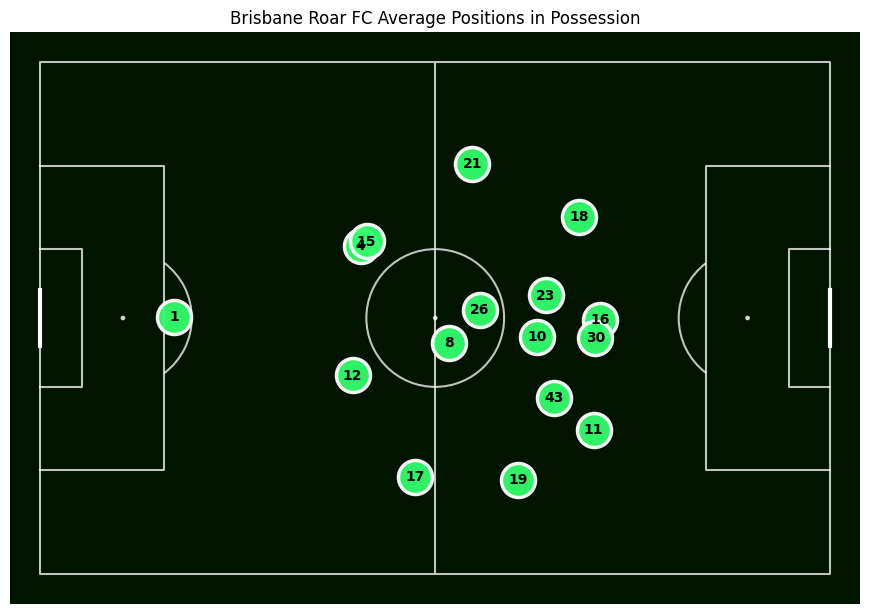

In [29]:
pitch = Pitch(
    pitch_type="skillcorner",
    line_alpha=0.75,
    pitch_length=105,
    pitch_width=68,
    pitch_color="#001400",
    line_color="white",
    linewidth=1.5,
)
fig, ax = pitch.grid(figheight=8, endnote_height=0, title_height=0)

viz_ip = aggregated_df[
    (aggregated_df["possession_flag"] == possession)
    & (aggregated_df["team_name"] == team)
].reset_index(drop=True)

ax.scatter(
    viz_ip["x"],
    viz_ip["y"],
    c="#32FE6B",
    alpha=0.95,
    s=600,
    edgecolors="white",
    linewidths=2.5,
    zorder=10,
    label="team",
)

# Annotate player numbers
for i, row in viz_ip.iterrows():
    ax.text(
        row["x"],
        row["y"],
        str(row["number"]),
        color="black",
        fontweight="bold",
        fontsize=10,
        ha="center",
        va="center",
        zorder=16,
    )

ax.set_title(f"{team} Average Positions in Possession")

In [31]:
aggregated_df["start_time"].unique()

array(['01:21:43', '00:00:00', '01:00:10', '01:14:32', '01:00:45',
       '01:14:54', '01:20:27', '01:25:21', '01:08:31', '00:48:03',
       '01:02:21', '01:09:53', '00:58:04', '01:19:39', '01:10:46',
       '00:57:49', '01:09:04', '01:19:48', '01:04:44', '00:55:22',
       '00:47:27', '01:25:04', '01:26:20', '01:23:12', '00:55:46',
       '01:06:43', '00:33:06', '01:13:42', '00:21:41', '01:16:45',
       '01:07:47', '01:16:37', '01:02:28', '01:13:36', '01:24:10',
       '00:58:58', '01:02:22', '01:00:15', '01:09:12', '01:26:46',
       '00:39:39', '01:01:40', '01:07:43', '00:48:16', '00:53:51',
       '01:22:15', '01:24:58', '01:19:45', '01:18:47', '01:24:41',
       '00:45:00', '01:14:27', '01:19:59', '01:22:37', '01:21:18',
       '01:11:13', '01:09:44', '01:24:01', '01:34:37', '01:33:43',
       '01:23:41', '01:26:57'], dtype=object)

Text(0.5, 1.0, 'Brisbane Roar FC Average Positions in Possession')

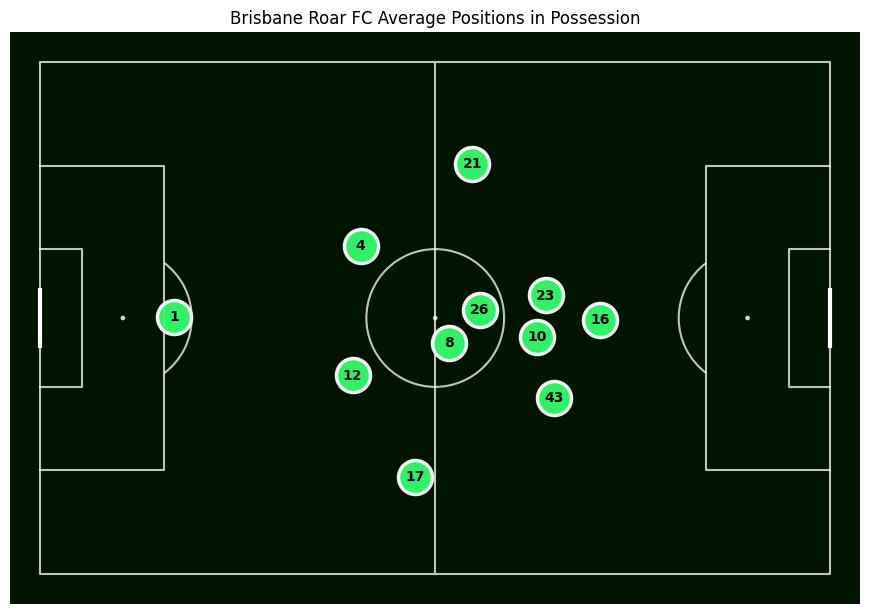

In [34]:
pitch = Pitch(
    pitch_type="skillcorner",
    line_alpha=0.75,
    pitch_length=105,
    pitch_width=68,
    pitch_color="#001400",
    line_color="white",
    linewidth=1.5,
)
fig, ax = pitch.grid(figheight=8, endnote_height=0, title_height=0)

viz_ip = aggregated_df[
    (aggregated_df["possession_flag"] == possession)
    & (aggregated_df["team_name"] == team)
    & (aggregated_df["start_time"] == "00:00:00")
].reset_index(drop=True)


ax.scatter(
    viz_ip["x"],
    viz_ip["y"],
    c="#32FE6B",
    alpha=0.95,
    s=600,
    edgecolors="white",
    linewidths=2.5,
    zorder=10,
    label="team",
)


# Annotate player numbers
for i, row in viz_ip.iterrows():
    ax.text(
        row["x"],
        row["y"],
        str(row["number"]),
        color="black",
        fontweight="bold",
        fontsize=10,
        ha="center",
        va="center",
        zorder=16,
    )

ax.set_title(f"{team} Average Positions in Possession")

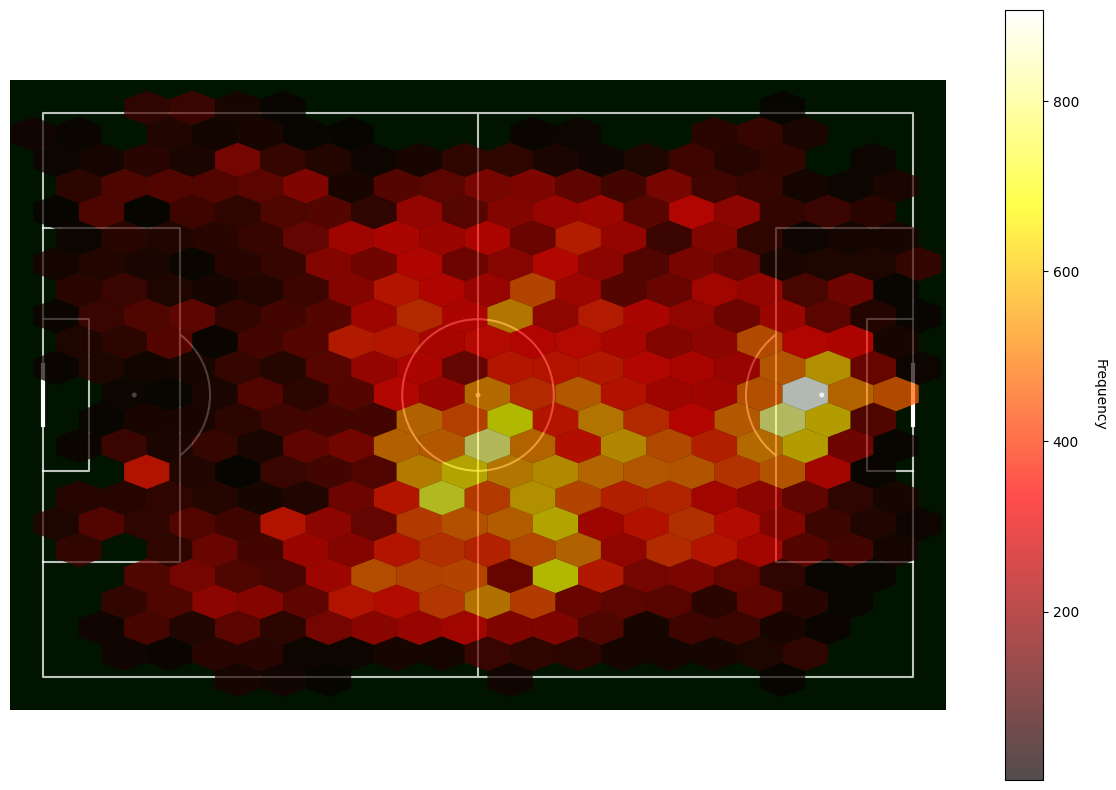

In [38]:
from matplotlib.colors import LinearSegmentedColormap

import matplotlib.pyplot as plt

# Create pitch
pitch = Pitch(
    pitch_type="skillcorner",
    line_alpha=0.75,
    pitch_length=105,
    pitch_width=68,
    pitch_color="#001400",
    line_color="white",
    linewidth=1.5,
)

# Select a player to visualize
player_id = 23909  # You can change this to any player_id from the tracking data
player_name = merged_df[merged_df['player_id'] == player_id]['short_name'].values[0]
player_number = merged_df[merged_df['player_id'] == player_id]['number'].values[0]

# Filter tracking data for the selected player
player_tracking = merged_df[
    merged_df['player_id'] == player_id
].copy()

# Adjust coordinates based on direction (similar to what was done in filtered_df)
player_tracking["direction_player"] = np.where(
    player_tracking["period"] == 1,
    player_tracking["direction_player_1st_half"],
    player_tracking["direction_player_2nd_half"],
)
player_tracking["x_adjusted"] = np.where(
    player_tracking["direction_player"] == "right_to_left",
    -player_tracking["x"],
    player_tracking["x"],
)
player_tracking["y_adjusted"] = np.where(
    player_tracking["direction_player"] == "right_to_left",
    -player_tracking["y"],
    player_tracking["y"],
)

# Create figure
fig, ax = pitch.draw(figsize=(12, 8))

# Create heatmap using hexbin
heatmap = ax.hexbin(
    player_tracking['x_adjusted'],
    player_tracking['y_adjusted'],
    gridsize=20,
    cmap='hot',
    alpha=0.7,
    edgecolors='none',
    mincnt=1
)

# Add colorbar
cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label('Frequency', rotation=270, labelpad=20)

# Add title
plt.title(
    f"Heat Map: {player_name} (#{player_number}) - Full Match Movement",
    fontsize=14,
    fontweight='bold',
    color='white'
)

plt.tight_layout()
fig.show()